In [18]:
!pip install mediapipe==0.10.30 opencv-python pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 60.5 MB/s eta 0:00:00
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 1.0.1
    Uninstalling mediapipe-1.0.1:
      Successfully uninstalled mediapipe-1.0.1


In [2]:
import cv2 #görüntü/video işleme
import mediapipe as mp #insan vücudu noktalarını bulur
import numpy as np #matematiksel işlemler
import pandas as pd #elde ettiğimiz verileri tablo haline getirir
import matplotlib.pyplot as plt #grafik oluşturur

print("Kütüphaneler hazır!")

Kütüphaneler hazır!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving squat.jpeg to squat.jpeg


In [4]:
# Fotoğrafı bilgisayardan okuyalım
image = cv2.imread("squat.jpeg")

# Fotoğrafın boyutlarını kontrol edelim
print(image.shape)

(280, 389, 3)


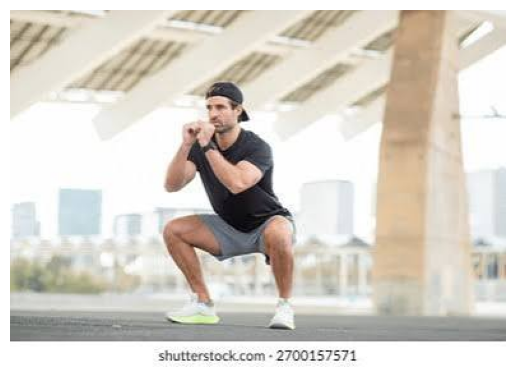

In [5]:
# Fotoğrafı ekranda gösterelim
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [2]:
import mediapipe as mp

print(mp.__version__)

0.10.30


In [7]:
# MediaPipe'ın güncel Pose Landmarker aracını içe aktarıyoruz
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("Pose Landmarker hazır!")

Pose Landmarker hazır!


In [8]:
!rm -f /content/pose_landmarker.task

!wget -O /content/pose_landmarker.task \
"https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/1/pose_landmarker_full.task"

--2026-09-23 14:57:56--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/1/pose_landmarker_full.task
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.184.207, 172.253.155.207, 142.251.183.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.184.207|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-23 14:57:56 ERROR 404: Not Found.



In [10]:
# Eski, boş model dosyasını siliyoruz
!rm -f /content/pose_landmarker.task

# Güncel MediaPipe Pose Landmarker Full modelini indiriyoruz
!wget -O /content/pose_landmarker.task \
"https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"

# Dosyanın gerçekten indiğini kontrol ediyoruz
import os

model_path = "/content/pose_landmarker.task"

print("Dosya var mı:", os.path.exists(model_path))
print("Dosya boyutu:", os.path.getsize(model_path), "byte")

--2026-09-23 15:00:05--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.183.207, 192.178.210.207, 192.178.129.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.183.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9398198 (9.0M) [application/octet-stream]
Saving to: ‘/content/pose_landmarker.task’

/content/pose_landm 100%[===================>]   8.96M  --.-KB/s    in 0.09s   

2026-09-23 15:00:05 (101 MB/s) - ‘/content/pose_landmarker.task’ saved [9398198/9398198]

Dosya var mı: True
Dosya boyutu: 9398198 byte


In [11]:
# MediaPipe Tasks API
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Model dosyasının konumu
base_options = python.BaseOptions(
    model_asset_path="/content/pose_landmarker.task"
)

# Pose Landmarker ayarları
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False
)

# Modeli oluşturuyoruz
detector = vision.PoseLandmarker.create_from_options(options)

print("Model çalışmaya hazır!")

Model çalışmaya hazır!


In [12]:
# Fotoğrafı MediaPipe'ın anlayacağı formata çeviriyoruz
image = mp.Image.create_from_file("/content/squat.jpeg")

# Fotoğraftaki vücut noktalarını tespit ediyoruz
detection_result = detector.detect(image)

print("Vücut analizi tamamlandı!")

Vücut analizi tamamlandı!


In [13]:
# Kaç kişinin tespit edildiğini kontrol ediyoruz
print("Tespit edilen kişi sayısı:", len(detection_result.pose_landmarks))

# İlk kişinin vücut noktalarını kontrol ediyoruz
if detection_result.pose_landmarks:
    print("Vücut noktası sayısı:", len(detection_result.pose_landmarks[0]))

Tespit edilen kişi sayısı: 1
Vücut noktası sayısı: 33


In [14]:
# İlk kişinin 33 vücut noktasını alıyoruz
landmarks = detection_result.pose_landmarks[0]

# İlgili noktaları seçiyoruz
left_hip = landmarks[23]
left_knee = landmarks[25]
left_ankle = landmarks[27]

print("Sol kalça:", left_hip)
print("Sol diz:", left_knee)
print("Sol ayak bileği:", left_ankle)

Sol kalça: NormalizedLandmark(x=0.516036868095398, y=0.5998111963272095, z=-0.0684870183467865, visibility=0.9998373985290527, presence=0.9997019171714783, name=None)
Sol diz: NormalizedLandmark(x=0.5371385812759399, y=0.6181101202964783, z=-0.5149305462837219, visibility=0.9967982172966003, presence=0.9998956918716431, name=None)
Sol ayak bileği: NormalizedLandmark(x=0.5522438287734985, y=0.8254486322402954, z=-0.4772193431854248, visibility=0.9847161769866943, presence=0.9990090131759644, name=None)


In [15]:
import numpy as np

# Noktaların x-y koordinatlarını alıyoruz
hip = np.array([left_hip.x, left_hip.y])
knee = np.array([left_knee.x, left_knee.y])
ankle = np.array([left_ankle.x, left_ankle.y])

# Dizden kalçaya ve ayak bileğine doğru iki vektör oluşturuyoruz
vector1 = hip - knee
vector2 = ankle - knee

# İki vektör arasındaki açıyı hesaplıyoruz
cos_angle = np.dot(vector1, vector2) / (
    np.linalg.norm(vector1) * np.linalg.norm(vector2)
)

angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

print("Sol diz açısı:", round(angle, 2), "derece")

Sol diz açısı: 135.1 derece


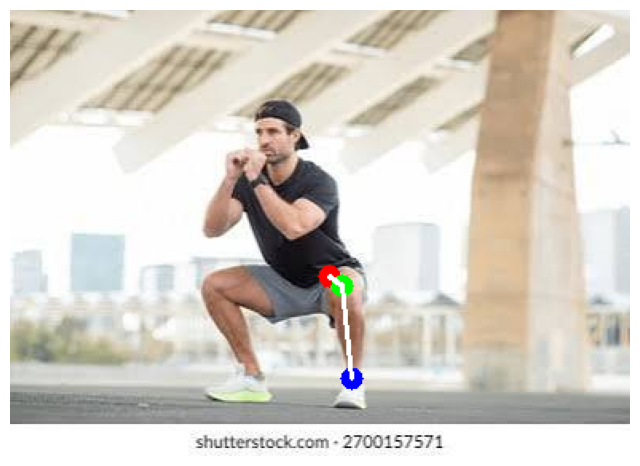

In [17]:
# OpenCV'yi tekrar içe aktarıyoruz
import cv2
import matplotlib.pyplot as plt

# MediaPipe görüntüsünü NumPy dizisine çeviriyoruz
image_rgb = image.numpy_view().copy()

height, width = image_rgb.shape[:2]

# Noktaların piksel koordinatlarını hesaplıyoruz
hip_point = (
    int(left_hip.x * width),
    int(left_hip.y * height)
)

knee_point = (
    int(left_knee.x * width),
    int(left_knee.y * height)
)

ankle_point = (
    int(left_ankle.x * width),
    int(left_ankle.y * height)
)

# Noktaları çiziyoruz
cv2.circle(image_rgb, hip_point, 7, (255, 0, 0), -1)
cv2.circle(image_rgb, knee_point, 7, (0, 255, 0), -1)
cv2.circle(image_rgb, ankle_point, 7, (0, 0, 255), -1)

# Kalça-diz ve diz-ayak bileğini bağlıyoruz
cv2.line(image_rgb, hip_point, knee_point, (255, 255, 255), 2)
cv2.line(image_rgb, knee_point, ankle_point, (255, 255, 255), 2)

# Görüntüyü göster
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [18]:
from google.colab import files

uploaded_video = files.upload()

Saving The Beginner's Squat_ Perfect this Basic Bodyweight Squat.mp4 to The Beginner's Squat_ Perfect this Basic Bodyweight Squat.mp4


In [19]:
import cv2

video_path = "/content/The Beginner's Squat_ Perfect this Basic Bodyweight Squat.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("FPS:", fps)
print("Kare sayısı:", frame_count)
print("Video boyutu:", width, "x", height)
print("Video süresi:", round(duration, 2), "saniye")

cap.release()

FPS: 30.0
Kare sayısı: 331
Video boyutu: 720 x 1280
Video süresi: 11.03 saniye


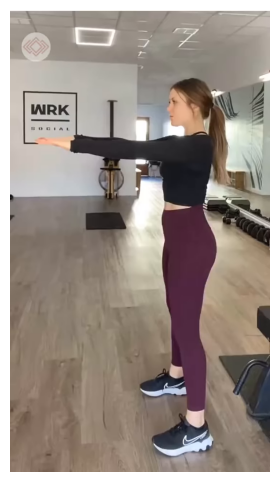

In [20]:
import cv2
import matplotlib.pyplot as plt

video_path = "/content/The Beginner's Squat_ Perfect this Basic Bodyweight Squat.mp4"

cap = cv2.VideoCapture(video_path)

# İlk kareyi oku
success, frame = cap.read()

cap.release()

if success:
    # OpenCV BGR -> RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()
else:
    print("Video karesi okunamadı.")

In [21]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd

video_path = "/content/The Beginner's Squat_ Perfect this Basic Bodyweight Squat.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

results = []

frame_number = 0

while True:
    success, frame = cap.read()

    if not success:
        break

    # Her 3 karede bir analiz yap
    if frame_number % 3 == 0:

        # OpenCV BGR -> RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # MediaPipe görüntüsü oluştur
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=frame_rgb
        )

        # Pose analizi
        detection = detector.detect(mp_image)

        # Eğer insan bulunduysa
        if detection.pose_landmarks:

            landmarks = detection.pose_landmarks[0]

            # Sol kalça, diz ve ayak bileği
            hip = landmarks[23]
            knee = landmarks[25]
            ankle = landmarks[27]

            # Koordinatları NumPy dizisine çevir
            hip_point = np.array([hip.x, hip.y])
            knee_point = np.array([knee.x, knee.y])
            ankle_point = np.array([ankle.x, ankle.y])

            # Vektörler
            vector1 = hip_point - knee_point
            vector2 = ankle_point - knee_point

            # Diz açısı
            cos_angle = np.dot(vector1, vector2) / (
                np.linalg.norm(vector1) * np.linalg.norm(vector2)
            )

            angle = np.degrees(
                np.arccos(np.clip(cos_angle, -1.0, 1.0))
            )

            # Sonucu kaydet
            results.append({
                "frame": frame_number,
                "time": frame_number / fps,
                "knee_angle": angle
            })

    frame_number += 1

cap.release()

# Sonuçları tabloya dönüştür
df = pd.DataFrame(results)

print("Toplam ölçüm:", len(df))
print()
print(df.head())

Toplam ölçüm: 109

   frame  time  knee_angle
0      0   0.0  169.033811
1      3   0.1  166.635173
2      6   0.2  166.429142
3      9   0.3  165.525592
4     12   0.4  159.660260


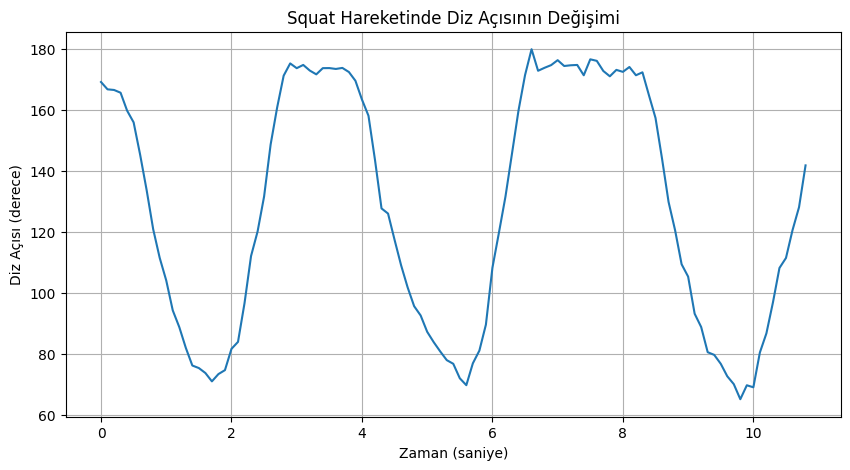

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(df["time"], df["knee_angle"])

plt.xlabel("Zaman (saniye)")
plt.ylabel("Diz Açısı (derece)")
plt.title("Squat Hareketinde Diz Açısının Değişimi")

plt.grid(True)
plt.show()

In [23]:
max_angle = df["knee_angle"].max()
min_angle = df["knee_angle"].min()

print("En büyük diz açısı:", round(max_angle, 2), "derece")
print("En küçük diz açısı:", round(min_angle, 2), "derece")

En büyük diz açısı: 179.77 derece
En küçük diz açısı: 65.13 derece


In [24]:
min_index = df["knee_angle"].idxmin()

min_angle = df.loc[min_index, "knee_angle"]
min_time = df.loc[min_index, "time"]

print("En düşük diz açısı:", round(min_angle, 2), "derece")
print("En düşük açının gerçekleştiği zaman:", round(min_time, 2), "saniye")

En düşük diz açısı: 65.13 derece
En düşük açının gerçekleştiği zaman: 9.8 saniye


In [25]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    -df["knee_angle"],
    distance=15,
    prominence=10
)

print("Tahmini squat sayısı:", len(peaks))

for i, peak in enumerate(peaks, start=1):
    print(
        f"{i}. squat → "
        f"{df.loc[peak, 'time']:.2f} saniye, "
        f"{df.loc[peak, 'knee_angle']:.2f} derece"
    )

Tahmini squat sayısı: 3
1. squat → 1.70 saniye, 70.98 derece
2. squat → 5.60 saniye, 69.73 derece
3. squat → 9.80 saniye, 65.13 derece


In [26]:
squat_angles = df.loc[peaks, "knee_angle"]

average_min_angle = squat_angles.mean()

print("Toplam squat:", len(peaks))
print("Ortalama minimum diz açısı:", round(average_min_angle, 2), "derece")
print("En düşük diz açısı:", round(squat_angles.min(), 2), "derece")

Toplam squat: 3
Ortalama minimum diz açısı: 68.61 derece
En düşük diz açısı: 65.13 derece


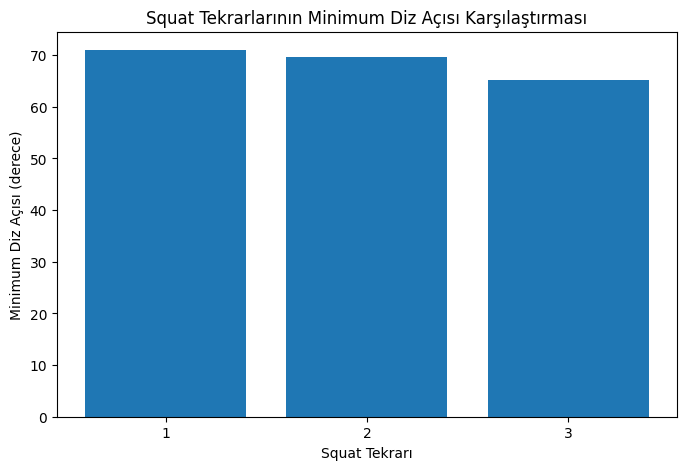

In [27]:
squat_numbers = [1, 2, 3]
squat_angles = df.loc[peaks, "knee_angle"].values

plt.figure(figsize=(8, 5))

plt.bar(squat_numbers, squat_angles)

plt.xlabel("Squat Tekrarı")
plt.ylabel("Minimum Diz Açısı (derece)")
plt.title("Squat Tekrarlarının Minimum Diz Açısı Karşılaştırması")

plt.xticks(squat_numbers)
plt.show()

In [28]:
first_squat = df.loc[peaks[0], "knee_angle"]
last_squat = df.loc[peaks[-1], "knee_angle"]

change_percent = ((last_squat - first_squat) / first_squat) * 100

print("İlk squat minimum açısı:", round(first_squat, 2), "derece")
print("Son squat minimum açısı:", round(last_squat, 2), "derece")
print("Değişim:", round(change_percent, 2), "%")

İlk squat minimum açısı: 70.98 derece
Son squat minimum açısı: 65.13 derece
Değişim: -8.24 %


In [29]:
df.to_csv("squat_knee_angle_analysis.csv", index=False)

print("CSV dosyası oluşturuldu.")

CSV dosyası oluşturuldu.


In [30]:
print("===== SQUAT HAREKET ANALİZİ =====")
print()

print("Toplam squat:", len(peaks))
print("Ortalama minimum diz açısı:", round(average_min_angle, 2), "derece")
print("En düşük diz açısı:", round(min_angle, 2), "derece")
print("En düşük açının gerçekleştiği zaman:", round(min_time, 2), "saniye")
print("İlk squat minimum açısı:", round(first_squat, 2), "derece")
print("Son squat minimum açısı:", round(last_squat, 2), "derece")
print("İlk-son squat değişimi:", round(change_percent, 2), "%")

===== SQUAT HAREKET ANALİZİ =====

Toplam squat: 3
Ortalama minimum diz açısı: 68.61 derece
En düşük diz açısı: 65.13 derece
En düşük açının gerçekleştiği zaman: 9.8 saniye
İlk squat minimum açısı: 70.98 derece
Son squat minimum açısı: 65.13 derece
İlk-son squat değişimi: -8.24 %


In [31]:
summary = pd.DataFrame({
    "metric": [
        "Toplam squat",
        "Ortalama minimum diz açısı",
        "En düşük diz açısı",
        "En düşük açı zamanı",
        "İlk squat minimum açısı",
        "Son squat minimum açısı",
        "İlk-son squat değişimi"
    ],
    "value": [
        len(peaks),
        round(average_min_angle, 2),
        round(min_angle, 2),
        round(min_time, 2),
        round(first_squat, 2),
        round(last_squat, 2),
        round(change_percent, 2)
    ]
})

summary.to_csv("squat_analysis_summary.csv", index=False)

print(summary)

                       metric  value
0                Toplam squat   3.00
1  Ortalama minimum diz açısı  68.61
2          En düşük diz açısı  65.13
3         En düşük açı zamanı   9.80
4     İlk squat minimum açısı  70.98
5     Son squat minimum açısı  65.13
6      İlk-son squat değişimi  -8.24


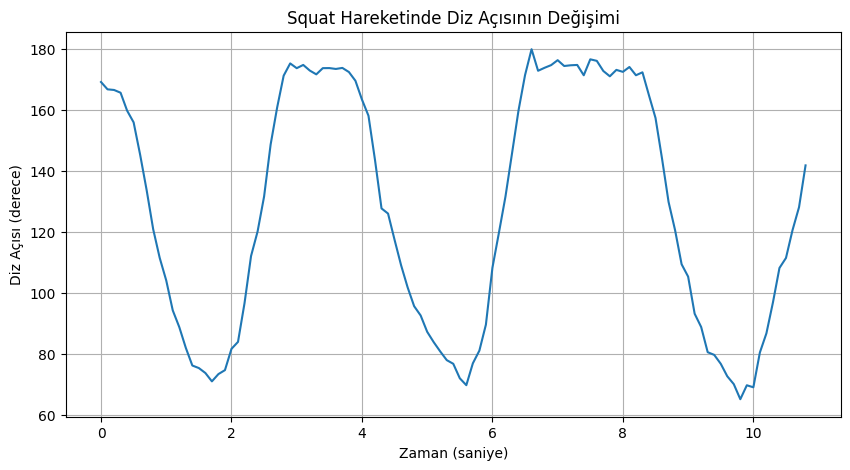

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(df["time"], df["knee_angle"])

plt.xlabel("Zaman (saniye)")
plt.ylabel("Diz Açısı (derece)")
plt.title("Squat Hareketinde Diz Açısının Değişimi")
plt.grid(True)

plt.savefig("knee_angle_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

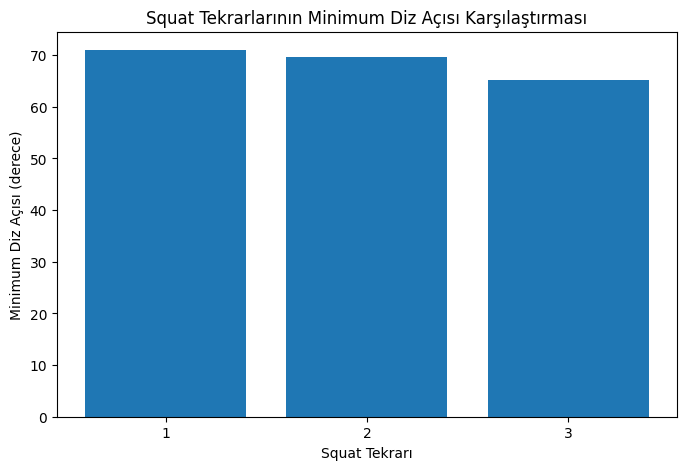

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(squat_numbers, squat_angles)

plt.xlabel("Squat Tekrarı")
plt.ylabel("Minimum Diz Açısı (derece)")
plt.title("Squat Tekrarlarının Minimum Diz Açısı Karşılaştırması")

plt.xticks(squat_numbers)

plt.savefig("squat_comparison.png", dpi=300, bbox_inches="tight")
plt.show()